(00-01-rendementen)=

# Rendementen en hun statistiek

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1926–2026. Dit is geen tijdvak maar een meetlat voor de rest van de
reeks.

**Wat we al weten.** [De vorige lecture](#00-00-setup) zette de gereedschapskist
neer: acht gratis databronnen, een notatie en een handvol schatters. Ze eindigde
met één getal: het rekenkundig gemiddelde marktrendement over honderd jaar is
11,6% per jaar, met een standaardfout van 1,8 procentpunt. Wat een rendement
precies is, bleef daar open.

**Welke vraag staat open.** Wat meten we als we een gemiddeld rendement
uitrekenen, en hoe nauwkeurig is die meting?
```

## Overzicht

Wat meten we als we een gemiddeld rendement uitrekenen, en hoe nauwkeurig? We
schatten het verwachte rendement, en dat heeft na een eeuw data nog een
standaardfout van twee procentpunt, terwijl de volatiliteit dan al bijna exact
vastligt. In deze lecture:

- leggen we het verschil vast tussen simpele rendementen en logrendementen, en
  leiden we af dat het meetkundig gemiddelde een halve variantie onder het
  rekenkundige ligt;

- leiden we de standaardfout van het gemiddelde af, en daarmee
  [de standaardfout van 2%](#sec-rendementen-standaardfout): bij 20%
  volatiliteit per jaar is het gemiddelde na een eeuw op twee procentpunt na
  bekend;

- bewijzen we met de stelling van Merton dat vaker meten daar niets aan
  verandert, en simuleren we dat op tweeduizend eeuwen;

- repliceren we het eerste gemeten gemiddelde rendement op aandelen, en zetten
  we er de standaardfout bij.

Het Center for Research in Security Prices (CRSP) zette in de jaren zestig de
koersen van alle NYSE-aandelen vanaf 1926 op magneetband. Op die tape
rapporteerden Lawrence Fisher en James Lorie in 1964 het gemiddelde rendement op
Amerikaanse aandelen over 1926–1960 {cite}`FisherLorie1964`. Hun 9,0% per jaar
was de eerste betrouwbare meting van die grootheid, zonder standaardfout.
{cite:t}`Merton1980` gaf zestien jaar later de scherpe vorm van het probleem: de
precisie van een geschat verwacht rendement hangt alleen af van de
kalenderlengte van de steekproef. Door de reeks loopt de vraag theorie of feit:
is een model een theorie die getoetst wordt, of een feit dat op een verklaring
wacht? Deze lecture is een uitzondering: ze toetst geen theorie, want haar
stellingen zijn wiskundig waar. Wel bepalen ze welke latere theorieën toetsbaar zijn.

## Intuïtie: waarom zou dit waar zijn?

Denk aan iemand die met een meetpaal wil weten hoe hard het gemiddeld waait. Ze
kan twee vragen stellen. Hoeveel lucht is er in totaal langsgekomen? En hoe hard
schommelt de wind?

Voor de eerste vraag maakt het niet uit hoe vaak ze meet. Wie elke seconde meet
in plaats van elk uur, krijgt 3600 keer zoveel getallen over dezelfde lucht. Het
totaal van het jaar ligt vast zodra het jaar voorbij is. Een beter gemiddelde
vraagt meer jaren, niet meer metingen per jaar. Voor de tweede vraag ligt het
omgekeerd: elke extra meting zegt iets over hoe hard het schommelt.

Voor een aandeel werkt het net zo. De totale koersverandering hangt alleen af
van begin- en eindkoers, en het gemiddelde rendement is die verandering gedeeld
door de tijd. Dagelijks meten geeft ruim 250 keer zoveel getallen, maar niet meer
informatie over het gemiddelde. De *volatiliteit* (de standaarddeviatie van het
rendement, per jaar) wordt daarentegen bij elke verfijning scherper.

Daar komt een tweede asymmetrie bij. Een verlies van 20% en een winst van 25%
heffen elkaar op in niveaus: $0{,}80 \times 1{,}25 = 1$. Het rekenkundig
gemiddelde is toch $+2{,}5\%$, terwijl het vermogen gelijk bleef. Rendementen
vermenigvuldigen zich, gemiddelden tellen op, en het verschil groeit met de
schommelingen. Bij 20% volatiliteit is het $0{,}20^2/2 = 2$ procentpunt per jaar.

Met de getallen van de echte wereld worden beide observaties knellend. De
volatiliteit van aandelen is ongeveer 20% per jaar, de *equity premium* (het
extra rendement van aandelen boven de risicovrije rente, hierna de premie)
ongeveer 6%. Dat is een kalibratie, geen meting: {cite:t}`MehraPrescott1985`
vonden 6,18% over 1889–1978, en [](#00-00-setup) meet 8,3% op de French-data
sinds 1926. Het verschil komt van de periode. Voor de standaardfout doet het er
niet toe, want die hangt alleen van de volatiliteit af. Met 20% tegen 6% is de
ruis ruim drie keer zo groot als het signaal, en alleen
verstrijkende tijd maakt het signaal zichtbaar.

We verwachten dus drie dingen. Vaker meten maakt de volatiliteit scherper, maar
het gemiddelde niet. Het meetkundig gemiddelde ligt onder het rekenkundige,
verder naarmate de schommelingen groter zijn. En omdat de ruis zo veel groter is
dan het signaal, blijft het gemiddelde ook na een eeuw onzeker, met een fout van
enkele procentpunten.

## Toy-voorbeeld: drie jaar rendement, met de hand

Eerst laden we de pakketten die de hele lecture gebruikt.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

**Opzet.** Een belegging doet in drie
jaar het volgende:

| jaar | netto rendement $r$ | bruto rendement $R = 1 + r$ |
|---|---|---|
| 1 | $+0{,}25$ | $1{,}25$ |
| 2 | $-0{,}20$ | $0{,}80$ |
| 3 | $+0{,}10$ | $1{,}10$ |

Het mechanisme is één ongelijkheid: het rekenkundig gemiddelde ligt boven het
meetkundige. **Het recept**, dat de theorie als eerste afleidt: het meetkundig
gemiddelde is ongeveer het rekenkundig gemiddelde min een halve variantie.

**Stap 1: het rekenkundig gemiddelde.** Optellen en delen door drie:

$$
\bar r = \frac{0{,}25 - 0{,}20 + 0{,}10}{3} = \frac{0{,}15}{3} = 0{,}05 .
$$

**Stap 2: het meetkundig gemiddelde.** Het product van de bruto rendementen is
$1{,}25 \times 0{,}80 \times 1{,}10 = 1{,}10$. Eén euro is na drie jaar $1{,}10$
euro geworden, en het meetkundig gemiddelde is

$$
\bar R_g = 1{,}10^{1/3} = 1{,}032280, \qquad \text{dus } 3{,}2280\% \text{ per jaar.}
$$

Het verschil met het rekenkundig gemiddelde is $5 - 3{,}2280 = 1{,}772$
procentpunt. Dat is geen afrondingsfout. Over dertig jaar is het het verschil
tussen $1{,}05^{30} = 4{,}32$ en $1{,}03228^{30} = 2{,}59$ euro: twee derde meer.

**Stap 3: de logrendementen.** Ze zijn $\log 1{,}25 = 0{,}223144$,
$\log 0{,}80 = -0{,}223144$ en $\log 1{,}10 = 0{,}095310$. De eerste twee vallen
tegen elkaar weg. Daarom is 20% verlies pas met 25% winst goedgemaakt. Het
gemiddelde is $0{,}031770$, en $e^{0{,}031770} - 1 = 0{,}032280$. Het gemiddelde
logrendement is dus het meetkundig gemiddelde in een andere schrijfwijze.

**Stap 4: het recept.** De afwijkingen van $\bar r = 0{,}05$ zijn $0{,}20$,
$-0{,}25$ en $0{,}05$. Hun kwadraten tellen op tot
$0{,}04 + 0{,}0625 + 0{,}0025 = 0{,}105$. Gedeeld door drie is dat
$\hat\sigma^2 = 0{,}035$, en de halve variantie is $0{,}0175$. Het recept geeft
$0{,}05 - 0{,}0175 = 0{,}0325$, tegen de exacte $0{,}032280$: twee honderdste
procentpunt ernaast, bij drie waarnemingen.

De codecel rekent dezelfde getallen na en zet ze naast de handberekening.

In [2]:
r = np.array([0.25, -0.20, 0.10])
gross = 1 + r

arith = r.mean()
geom = gross.prod() ** (1 / len(r)) - 1
log_returns = np.log(gross)
geom_via_log = np.exp(log_returns.mean()) - 1
recipe = arith - r.var(ddof=0) / 2

rows = ["rekenkundig gemiddelde", "meetkundig gemiddelde",
        "via gemiddeld logrendement", "recept: gemiddelde - halve variantie",
        "verschil rekenkundig - meetkundig"]
by_hand = [0.05, 0.032280, 0.032280, 0.0325, 0.017720]
by_code = [arith, geom, geom_via_log, recipe, arith - geom]

pd.DataFrame({"met de hand": by_hand, "code": by_code}, index=rows).round(6)

,met de hand,code
rekenkundig gemiddelde,0.05000,0.05000
meetkundig gemiddelde,0.03228,0.03228
via gemiddeld logrendement,0.03228,0.03228
recept: gemiddelde - halve variantie,0.03250,0.03250
verschil rekenkundig - meetkundig,0.01772,0.01772


De twee kolommen zijn gelijk, en het recept zit er 0,00022 naast. Wat de lezer
nu weet: het meetkundig gemiddelde ligt ongeveer een halve variantie onder het
rekenkundige. Dezelfde drie jaren geven in de theorie ook een eerste
standaardfout.

## Theorie

We leiden drie resultaten af. Eerst het recept uit het toy-voorbeeld: het
meetkundig gemiddelde ligt een halve variantie onder het rekenkundige. Dan de
kern: de standaardfout van het gemiddelde, en daarmee
[de standaardfout van 2%](#sec-rendementen-standaardfout). Ten slotte de
stelling van Merton, die zegt waarom vaker meten die standaardfout niet
verkleint. Aan het eind kijken we wat autocorrelatie en dikke staarten
veranderen.

### Opzet: twee soorten rendement

Er zijn twee rendementen nodig, omdat een belegger op twee manieren optelt: over
de tijd en over aandelen. Laat $p_t$ de prijs zijn en $d_{t+1}$ het dividend dat
tussen $t$ en $t+1$ wordt uitgekeerd, beide als niveaus, zoals in de hele reeks. Het *simpele* netto rendement en het bruto
rendement zijn

```{math}
:label: eq-rendementen-simpel
r_{t+1} = \frac{p_{t+1} + d_{t+1}}{p_t} - 1,
\qquad
R_{t+1} = 1 + r_{t+1} = \frac{p_{t+1} + d_{t+1}}{p_t} .
```

In woorden: het bruto rendement is wat een ingelegde euro na één periode waard
is, koers en dividend samen.

Zoals in [](#00-00-setup) is $r$ het netto simpele rendement, en krijgt het
*logrendement* een eigen symbool:

```{math}
:label: eq-rendementen-log
\ell_{t+1} \equiv \log R_{t+1} = \log\!\left(1 + r_{t+1}\right).
```

In woorden: $\ell$ is het groeitempo dat, continu doorgerekend, dezelfde euro
oplevert. Bij kleine rendementen liggen $\ell$ en $r$ dicht bij elkaar. Voor de
standaarddeviatie gebruiken we één symbool: vanaf hier is $\sigma$ de
volatiliteit van het logrendement. Die van het simpele rendement ligt er dicht
bij: voor de maandreeks over de hele eeuw 18,34% tegen 18,32% per jaar (de
dagtabel in de replicatie). Geen conclusie in deze lecture hangt van het verschil
af.

*Waarom zou dit waar zijn?* Een belegger die zijn vermogen twee jaar laat staan,
krijgt het product van twee bruto rendementen, $R_{t+1}R_{t+2}$. Wie simpele
rendementen over de tijd optelt, overschat dus wat hij overhoudt. Een belegger
die zijn euro's over aandelen verdeelt, krijgt de gewogen som van hun simpele
rendementen, want euro's tellen op. Wie daar logrendementen middelt, onderschat
het portefeuillerendement.

Over de **tijd** maken logaritmen van het product een som:

```{math}
:label: eq-rendementen-additief
\ell_{t \to t+k} = \sum_{j=1}^{k} \ell_{t+j} .
```

In woorden: het logrendement over $k$ perioden is de som van de logrendementen
per periode. Horizonnen en annualiseren zijn daarom natuurlijk in logs. Over de
**activa** tellen simpele rendementen op: een portefeuille met gewichten $w_i$
heeft rendement $r_p = \sum_i w_i r_i$. Bèta's en portefeuillekeuze op gemiddelde
en variantie zijn daarom natuurlijk in simpele rendementen.

```{warning}
De twee zijn niet uitwisselbaar. Uit $\log(1+x) = x - x^2/2 + \dots$ volgt dat
een maandrendement van 10% een logrendement van 9,53% geeft: bijna een half
procentpunt verschil in één maand. Wie een eeuw lang elke maand 10% simpel als
10% log boekt, overschat het eindvermogen met een factor
$e^{0{,}0047 \times 1200} \approx 280$.
```

### Meetkundig, rekenkundig en de variance drag

Het meetkundig gemiddelde ligt een halve variantie onder het rekenkundige. Dat
verschil heet de *variance drag* (de rem die schommelingen op de groei van een
vermogen zetten).

*Waarom zou dit waar zijn?* Een belegger die jaar na jaar zijn
vermogen laat staan, verdient een product. Na een daling van 50% is dan een
stijging van 100% nodig om terug te zijn. Het rekenkundig gemiddelde behandelt
$-50\%$ en $+100\%$ als een symmetrisch paar en ziet dat niet. Hoe groter de
schommelingen, hoe verder wat hij overhoudt achterblijft bij wat hij gemiddeld
verdient.

:::{prf:theorem} Variance drag
:label: thm-rendementen-drag

Zij $\ell_{t+1} = \log R_{t+1}$ onafhankelijk en gelijk verdeeld over de tijd,
normaal met gemiddelde $\nu$ en variantie $\sigma^2$. Dan is het verwachte
bruto rendement

```{math}
:label: eq-rendementen-lognormaal
\E[R_{t+1}] = \exp\!\left(\nu + \tfrac{1}{2}\sigma^{2}\right),
```

en voor het verwachte netto rendement $\mu_a$ en het meetkundige groeitempo
$\mu_g = e^{\nu}-1$ geldt

```{math}
:label: eq-rendementen-drag
\log(1+\mu_a) = \log(1+\mu_g) + \tfrac{1}{2}\sigma^{2},
\qquad\text{ofwel}\qquad
\mu_g \approx \mu_a - \tfrac{1}{2}\sigma^{2} .
```
:::

In woorden: [](#eq-rendementen-lognormaal) zegt dat de verwachting van een
lognormale variabele boven de exponent van haar gemiddelde ligt, en
[](#eq-rendementen-drag) dat het verwachte rendement daardoor een halve variantie
boven het meetkundige groeitempo ligt. Omdat het gemiddelde logrendement naar
$\nu$ convergeert (de wet van de grote aantallen), groeit een lang pad met $\mu_g$,
niet met $\mu_a$. Vier symbolen, twee grootheden: $\nu$ en $\mu_g = e^{\nu}-1$
beschrijven het groeitempo, $\mu_a$ het verwachte simpele rendement, dat in de
standaardfoutstelling kortweg $\mu$ heet. Het bewijs gebruikt de
momentgenererende functie van de normale verdeling en staat ingeklapt.

:::{prf:proof}
:class: dropdown

De momentgenererende functie van een normale variabele geeft
$\E[e^{\ell}] = e^{\nu + \sigma^2/2}$, wat
[](#eq-rendementen-lognormaal) is. Logaritme nemen levert
$\log \E[R] = \nu + \sigma^2/2$. Omdat $\E[R] = 1+\mu_a$ en
$e^{\nu} = 1+\mu_g$, is dat [](#eq-rendementen-drag). De benadering volgt uit
$\log(1+x)\approx x$. $\square$
:::

Het toy-voorbeeld liet het al zien: $5\% - 1{,}75\% = 3{,}25\%$, tegen exact
$3{,}23\%$. Zoals de intuïtie voorspelde, groeit het gat met de schommelingen:
een grotere variantie maakt het groter, een kleinere kleiner. Bij
$\sigma = 20\%$ is het 2 procentpunt per jaar, en over een eeuw een factor
$1{,}02^{100} \approx 7{,}2$ in eindvermogen.

Welk van de twee gemiddelden is het juiste? Beide, voor een andere vraag. Het
rekenkundig gemiddelde schat het verwachte rendement zuiver. Een prijs is een
verwachte uitkering, dus elke waarderingsformule in deze reeks gebruikt het
rekenkundige. Het meetkundig gemiddelde zegt wat een belegger na dertig jaar
overhoudt.

### Annualisatie en de wortel-$t$-regel

Over $k$ perioden groeit het verwachte logrendement met $k$ en de
standaarddeviatie met $\sqrt{k}$. *Waarom zou dit waar zijn?* Een belegger die $k$
jaar vasthoudt, ziet goede en slechte jaren elkaar deels opheffen. Zijn verwachte
opbrengst groeit met het aantal jaren, zijn spreiding trager. Zijn
$\ell_{t+1}$ onafhankelijk en gelijk verdeeld met gemiddelde $\nu$ en variantie
$\sigma^2$ per periode, dan volgt uit [](#eq-rendementen-additief)

```{math}
:label: eq-rendementen-wortelt
\E\!\left[\ell_{t\to t+k}\right] = k\,\nu,
\qquad
\Var\!\left(\ell_{t\to t+k}\right) = k\,\sigma^{2},
\qquad
\SD\!\left(\ell_{t\to t+k}\right) = \sqrt{k}\,\sigma .
```

In woorden: verwachting en variantie groeien met $k$, de standaarddeviatie met
$\sqrt{k}$. Met $n$ perioden per jaar ($n = 12$ voor maanddata) zijn de
geannualiseerde grootheden dus $n\bar\ell$ en $\sqrt{n}\,\hat\sigma$.

Uit die asymmetrie tussen $k$ en $\sqrt{k}$ volgt de rest van de lecture. De
verhouding van verwacht rendement tot standaarddeviatie, het signaal per eenheid
ruis, groeit daardoor met $\sqrt{k}$. Voor de markt is ze per dag 0,04: het
signaal is een vijfentwintigste van de ruis. Per jaar, met ongeveer 263
handelsdagen, is ze $0{,}04 \times \sqrt{263} \approx 0{,}65$. De dagtabel in de
replicatie rekent beide uit. Voor de premie heet deze verhouding de
*Sharpe-ratio*.

(sec-rendementen-standaardfout)=

### Het kernresultaat: de standaardfout van 2%

Een gemiddeld rendement wordt nauwkeuriger met de wortel van het aantal jaren,
niet met het aantal jaren zelf.

*Waarom zou dit waar zijn?* Een onderzoeker die
$T$ jaren middelt, laat toevallige goede en slechte jaren tegen elkaar wegvallen,
maar dat gaat langzaam. In de finance knelt dat: de volatiliteit is groot, de
premie klein, en het aantal jaren begrensd door de geschiedenis.

:::{prf:theorem} De standaardfout van het gemiddelde rendement
:label: thm-rendementen-se

Zij $r_1,\dots,r_T$ onafhankelijk en gelijk verdeeld met gemiddelde $\mu$ en
standaarddeviatie $\sigma$. Dan is $\bar r = T^{-1}\sum_t r_t$ zuiver en

```{math}
:label: eq-rendementen-se
\SD(\bar r) = \frac{\sigma}{\sqrt{T}} .
```
:::

:::{prf:proof}
$\Var(\bar r) = T^{-2}\sum_t \Var(r_t) = \sigma^2/T$, omdat de $r_t$ onafhankelijk
zijn en dezelfde variantie hebben.
$\square$
:::

In woorden: de standaardfout van het gemiddelde is de volatiliteit gedeeld door
de wortel van het aantal jaren. Ze geldt voor elke reeks rendementen, simpel of
log, premie of totaalrendement; alleen $\sigma$ verschilt. Voor de drie jaren uit het toy-voorbeeld schatten
we $\sigma$ met $s^2 = 0{,}105/2 = 0{,}0525$, dus $s = 22{,}9\%$. Delen door
$T - 1 = 2$ corrigeert ervoor dat het gemiddelde zelf geschat is. Stap 4 deelde
door drie en gaf 18,7%. Daar ging het om de drie jaren zelf, hier om het proces
waaruit ze komen. De standaardfout is dan $22{,}9/\sqrt{3} = 13{,}2$ procentpunt, ruim
tweeënhalf keer de 5% die we maten.

Met $\sigma = 20\%$ en $T = 100$ jaar is
$\SD(\bar r) = 20/\sqrt{100} = 2$ procentpunt. Dat is de standaardfout van 2%
waar deze reeks omheen is gebouwd: een eeuw data kent een gemiddeld jaarrendement
op twee procentpunt na. Een 95%-interval is ongeveer twee standaardfouten naar
weerszijden. Rond een geschatte premie van 6% loopt het van 2% tot 10%: van een
markt die risico nauwelijks beloont tot een die dat royaal doet.

Hoeveel jaren zijn nodig om een verschil te zien? De $t$-waarde van het
gemiddelde is $\mu\sqrt{T}/\sigma$. Stel die gelijk aan een gewenste $t$-waarde
$\tau$, bijvoorbeeld 2, en los op naar $T$:

```{math}
:label: eq-rendementen-jaren
T^{*} = \left(\frac{\tau\,\sigma}{\mu}\right)^{2} .
```

In woorden: het aantal benodigde jaren groeit kwadratisch naarmate het te vinden
verschil $\mu$ kleiner is. Om twee hypothesen $\mu_1 > \mu_0$ te scheiden,
vervangen we $\mu$ door $\mu_1 - \mu_0$.

Het antwoord heeft twee kanten. Om een premie van 6% met $\tau = 2$ van nul te
onderscheiden, zijn $(2 \times 0{,}20/0{,}06)^2 \approx 44$ jaar nodig. Daarom
betwijfelt vrijwel niemand dat er een premie is. Maar stel dat twee verklaringen
van de premie 4% en 6% voorspellen. Om die te scheiden zijn
$(2 \times 0{,}20/0{,}02)^2 = 400$ jaar nodig. De tabel rekent
[](#eq-rendementen-jaren) uit voor vijf vragen, bij $\sigma = 20\%$.

In [3]:
sigma = 0.20
targets = pd.DataFrame(
    {
        "vraag": [
            "premie van 6% onderscheiden van 0 (t=2)",
            "premie van 6% onderscheiden van 4% (t=2)",
            "premie van 6% onderscheiden van 5% (t=2)",
            "standaardfout van 1 procentpunt",
            "standaardfout van 0,5 procentpunt",
        ],
        "verschil (pp)": [6.0, 2.0, 1.0, np.nan, np.nan],
        "benodigde jaren": [
            (2 * sigma / 0.06) ** 2,
            (2 * sigma / 0.02) ** 2,
            (2 * sigma / 0.01) ** 2,
            (sigma / 0.01) ** 2,
            (sigma / 0.005) ** 2,
        ],
    }
).set_index("vraag")
targets.round(0)

,verschil (pp),benodigde jaren
vraag,,
premie van 6% onderscheiden van 0 (t=2),6.0,44.0
premie van 6% onderscheiden van 4% (t=2),2.0,400.0
premie van 6% onderscheiden van 5% (t=2),1.0,1600.0
standaardfout van 1 procentpunt,NaN,400.0
"standaardfout van 0,5 procentpunt",NaN,1600.0


Alleen de eerste vraag past binnen een eeuw. Of er een premie is, valt te
beantwoorden. Hoe groot hij is, vraagt honderden tot duizenden jaren. Zo lost de
theorie de derde voorspelling uit de intuïtie in.

### Merton (1980): waarom fijner meten niet helpt

Vaker kijken maakt de schatting van de variantie scherper, maar niet die van het
verwachte rendement. *Waarom zou dit waar zijn?* Een onderzoeker die het jaar
opknipt in maanden of minuten, verdeelt hetzelfde totale logrendement over meer
stukjes. Volgens [](#eq-rendementen-additief) is de som van die stukjes het
logrendement van begin tot eind, en dat verandert niet. De volatiliteit meet hij
met de som van de *kwadraten* van de stukjes, en meer kwadraten geven een
nauwkeuriger schatting.

In de stelling is $W_t$ een standaard Brownse beweging: een random walk in
continue tijd met $\Var(W_t) = t$. De drift $\nu$ is het verwachte logrendement
per jaar, en $\sigma$ zoals afgesproken de volatiliteit van het logrendement.
De *maximum-likelihoodschatters* zijn de parameters die de
waargenomen stappen het waarschijnlijkst maken. Bij normale stappen zijn dat het
gemiddelde en de variantie van de stappen.

:::{prf:theorem} Merton (1980): frequentie versus kalenderlengte
:label: thm-rendementen-merton

Zij de logprijs een Brownse beweging met drift,
$d\log p_t = \nu\,dt + \sigma\,dW_t$, waargenomen over $T$ jaar op $n$ tijdstippen
per jaar, dus met $N = nT$ waarnemingen. Dan hangt de precisie van de
maximum-likelihoodschatter van de drift alleen af van $T$, en die van de
variantie van $N$:

```{math}
:label: eq-rendementen-merton
\hat\nu = \frac{\log p_{T} - \log p_{0}}{T},
\qquad
\Var(\hat\nu) = \frac{\sigma^{2}}{T},
\qquad
\Var\!\left(\hat\sigma^{2}\right) \approx \frac{2\sigma^{4}}{N} = \frac{2\sigma^{4}}{nT} .
```
:::

In woorden: de geschatte drift is het totale logrendement gedeeld door het
aantal jaren. Zijn variantie hangt alleen van de kalenderlengte $T$ af, die van
$\hat\sigma^2$ van het aantal waarnemingen $N$. Het bewijs staat ingeklapt.

:::{prf:proof}
:class: dropdown

Met stapgrootte $\Delta = 1/n$ zijn de stappen
$\ell_i = \log p_{i\Delta}-\log p_{(i-1)\Delta}$, de logrendementen, onafhankelijk en
$N(\nu\Delta, \sigma^2\Delta)$. De ML-schatter van de drift is de gemiddelde stap
gedeeld door $\Delta$:

$$
\hat\nu = \frac{1}{N\Delta}\sum_{i=1}^{N}\ell_i
        = \frac{1}{T}\left(\log p_T - \log p_0\right),
$$

want in de som vallen alle tussenliggende koersen tegen elkaar weg. De variantie
is $\Var(\log p_T-\log p_0)/T^2 = \sigma^2 T/T^2 = \sigma^2/T$, onafhankelijk van $n$.

Voor de variantie: $\hat\sigma^2 = (N\Delta)^{-1}\sum_i (\ell_i - \bar\ell)^2$.
Omdat de stappen normaal zijn, is
$\sum_i(\ell_i-\bar\ell)^2/(\sigma^2\Delta) \sim \chi^2_{N-1}$, met variantie
$2(N-1)$. Dus $\Var(\hat\sigma^2) = 2\sigma^4(N-1)/N^2 \approx 2\sigma^4/N$.
$\square$
:::

De drift is een eigenschap van het pad als geheel. Honderd jaar dagkoersen
bevatten daarover evenveel informatie als twee koersen: de eerste en de laatste.
Alles daartussen zegt iets over de variantie. Bij 100 jaarwaarnemingen is de
relatieve standaardfout van de variantie $\sqrt{2/100} = 14\%$, bij
$100 \times 252 = 25\,200$ dagwaarnemingen 0,9%. Zo lost de stelling de eerste
voorspelling uit de intuïtie in: net als bij de windmeter verandert vaker meten
niets aan het totaal, en alles aan wat we over de schommeling weten.

### Wanneer de aannames niet gelden: autocorrelatie en dikke staarten

[De standaardfout van 2%](#sec-rendementen-standaardfout) blijft ook zonder
onafhankelijkheid en normaliteit vrijwel staan. Autocorrelatie maakt hem iets
groter, dikke staarten laten hem ongemoeid.

**Autocorrelatie.** *Waarom zou dit waar zijn?* Volgt op een goede maand vaak
weer een goede, dan versterken de schokken elkaar, en wordt de spreiding over een
jaar groter dan de wortel-$t$-regel zegt. Volgt op goed vaak slecht, dan wordt ze
kleiner. Laat $\rho_j = \Corr(\ell_t,\ell_{t-j})$ de autocorrelatie bij lag $j$
zijn: de correlatie tussen een rendement en dat van $j$ perioden eerder. Voor de
som van $q$ opeenvolgende logrendementen geldt

```{math}
:label: eq-rendementen-vr
\Var\!\left(\sum_{j=0}^{q-1}\ell_{t-j}\right)
= q\,\sigma^{2}
  \left[1 + 2\sum_{j=1}^{q-1}\left(1-\frac{j}{q}\right)\rho_j\right] .
```

In woorden: de variantie over $q$ perioden is $q$ keer de variantie per periode,
maal een correctie. Die correctie tussen haken heet de *variance ratio* $VR(q)$:
één onder een random walk, boven één bij positieve en onder één bij negatieve
autocorrelatie. De toets
erop is van {cite:t}`LoMacKinlay1988`.

De standaardfout van het gemiddelde krijgt dezelfde correctie. Met $N$
waarnemingen op één frequentie, en $\sigma$ en $VR$ op die frequentie, wordt
ze $\sigma\sqrt{VR(N)}/\sqrt{N}$. Neem maandrendementen: $N = 1200$ maanden,
met een autocorrelatie bij lag 1 van 0,085 (zie de replicatie). Met alleen die
ene autocorrelatie is $VR(1200) \approx 1 + 2 \times 0{,}085 = 1{,}17$, en de
standaardfout groeit met $\sqrt{1{,}17} \approx 1{,}08$: van 2,0 naar ongeveer 2,2
procentpunt. De conclusie verandert niet.

**Dikke staarten.** {cite:t}`Mandelbrot1963` en {cite:t}`Fama1965` lieten zien
dat dagelijkse koersveranderingen veel te veel massa in de staarten hebben voor
een normale verdeling. De maat is de *kurtosis*
$\kappa = \E[(\ell-\nu)^4]/\sigma^4$, het vierde gestandaardiseerde moment: drie
onder normaliteit. Tabellen rapporteren meestal de *excess kurtosis*
$\kappa - 3$. Voor dagelijkse logrendementen van de markt is die ongeveer
zeventien, zoals de replicatie laat zien, dus $\kappa \approx 20$.

De variantieschatter is een gemiddelde van $N$ gekwadrateerde afwijkingen, die we
nog wel onafhankelijk nemen. Eén kwadraat heeft variantie
$\E[(\ell-\nu)^4] - \sigma^4 = (\kappa - 1)\sigma^4$, dus

$$
\Var(\bar\ell) = \frac{\sigma^{2}}{T},
\qquad
\Var(\hat\sigma^{2}) = \frac{\sigma^{4}(\kappa-1)}{N} .
$$

Links staat het gemiddelde logrendement per jaar over $T$ jaar, met $\sigma$ per
jaar. Rechts staat de variantie per waarneming, geschat uit $N$ waarnemingen, met
$\sigma$ per waarneming. Bij $\kappa = 3$ staat er de $2\sigma^4/N$ van Merton.

De eerste formule bevat
geen kurtosis: zolang de variantie eindig is, laten dikke staarten de
standaardfout van het gemiddelde ongemoeid. De tweede wel. Bij $\kappa \approx 20$
is de standaardfout van de variantieschatting $\sqrt{19/2} \approx 3$ keer zo
groot als onder normaliteit. Dikke staarten kosten dus alleen precisie in de
grootheid die we al goed kenden.

```{admonition} Samengevat
:class: tip

- Het meetkundig gemiddelde ligt een halve variantie onder het rekenkundige,
  [](#eq-rendementen-drag).

- Over de tijd tellen logrendementen op, en de standaarddeviatie groeit met
  $\sqrt{k}$, [](#eq-rendementen-wortelt).

- De standaardfout van het gemiddelde is $\sigma/\sqrt{T}$,
  [](#eq-rendementen-se): bij $\sigma = 20\%$ en een eeuw data twee procentpunt.

- Die precisie hangt alleen af van de kalenderlengte, die van de variantie ook
  van de frequentie, [](#eq-rendementen-merton).

- De simulatie hierna vraagt: wat gebeurt er met beide standaardfouten als we
  dezelfde honderd jaar steeds fijner bekijken?
```

## Simulatie: de frequentie van waarnemen

De simulatie beantwoordt één vraag over steekproeven: wat gebeurt er met de
schatters van gemiddelde en variantie als we dezelfde honderd jaar steeds fijner
bekijken? We bouwen een
wereld waarin de logprijs een Brownse beweging volgt met een drift van 8% en een
volatiliteit van 20% per jaar. De 8% is de drift $\nu$ van het logrendement: een totaalrendement, geen premie.
Voor de standaardfout doet de drift er niet toe:
die hangt volgens [](#eq-rendementen-se) alleen van de 20% af.

We genereren tweeduizend paden van honderd jaar met 252 handelsdagen per jaar.
Elk pad bekijken we jaarlijks, per kwartaal, per maand en per dag: we lezen de
logprijs af op $k$ momenten per jaar, dus elke $252/k$-ste dagkoers, en nemen de
verschillen. De cel werkt in
acht blokken van 250 paden, om geheugen te sparen.

In [4]:
n_paths, n_years, per_year = 2000, 100, 252
nu, sigma_true = 0.08, 0.20
freqs = {"jaarlijks": 1, "kwartaal": 4, "maandelijks": 12, "dagelijks": 252}

means = {name: [] for name in freqs}
variances = {name: [] for name in freqs}

for block in np.array_split(np.arange(n_paths), 8):
    daily_steps = rng.normal(
        nu / per_year, sigma_true / np.sqrt(per_year),
        size=(len(block), n_years * per_year),
    )
    start = np.zeros((len(block), 1))
    log_price = np.hstack([start, daily_steps.cumsum(axis=1)])
    for name, k in freqs.items():
        step = per_year // k                            # dagen tussen twee waarnemingen
        observed = log_price[:, ::step]                 # elke step-de dagkoers
        returns_k = np.diff(observed, axis=1)          # logrendement per periode
        means[name].append(returns_k.mean(axis=1) * k)
        variances[name].append(returns_k.var(axis=1, ddof=1) * k)

means = {name: np.concatenate(v) for name, v in means.items()}
variances = {name: np.concatenate(v) for name, v in variances.items()}

Per frequentie hebben we nu tweeduizend geschatte gemiddelden en varianties. De
tabel zet hun spreiding naast de theorie.

In [5]:
frequency = pd.DataFrame(
    {
        "waarnemingen": [n_years * k for k in freqs.values()],
        "standaardfout gemiddelde (pp)": [means[n].std(ddof=1) * 100 for n in freqs],
        "theorie gemiddelde (pp)": [sigma_true / np.sqrt(n_years) * 100] * 4,
        "relatieve fout variantie": [
            variances[n].std(ddof=1) / sigma_true**2 for n in freqs
        ],
        "theorie variantie": [
            np.sqrt(2 / (n_years * k)) for k in freqs.values()
        ],
    },
    index=list(freqs),
)
frequency.round(4)

,waarnemingen,standaardfout gemiddelde (pp),theorie gemiddelde (pp),relatieve fout variantie,theorie variantie
jaarlijks,100,1.9928,2.0,0.1369,0.1414
kwartaal,400,1.9928,2.0,0.0695,0.0707
maandelijks,1200,1.9928,2.0,0.0403,0.0408
dagelijks,25200,1.9928,2.0,0.0091,0.0089


Het aantal waarnemingen groeit met een factor 252, maar de standaardfout van het
gemiddelde blijft exact 1,99 procentpunt. Volgens [](#eq-rendementen-merton) is
de schatter bij elke frequentie dezelfde functie van het pad: laatste min eerste
logprijs, gedeeld door honderd. De relatieve fout van de variantie daalt
intussen van 14% naar 0,9%, zoals $\sqrt{2/N}$ voorspelt.

De figuur toont beide schatters voor jaarlijkse en dagelijkse waarneming. Let op
de breedte van de histogrammen: links is maar één histogram zichtbaar, omdat de
twee exact samenvallen.

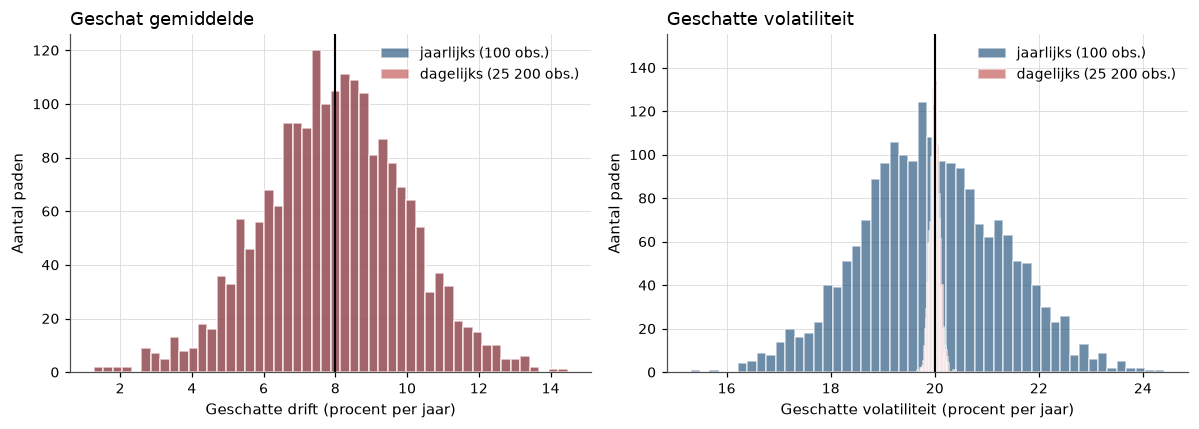

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

axes[0].hist(means["jaarlijks"] * 100, bins=50, alpha=0.65,
             label="jaarlijks (100 obs.)", edgecolor="white")
axes[0].hist(means["dagelijks"] * 100, bins=50, alpha=0.65,
             label="dagelijks (25 200 obs.)", edgecolor="white")
axes[0].axvline(nu * 100, color="black", lw=1.4)
axes[0].set_title("Geschat gemiddelde")
axes[0].set_xlabel("Geschatte drift (procent per jaar)")
axes[0].set_ylabel("Aantal paden")
axes[0].legend()

axes[1].hist(np.sqrt(variances["jaarlijks"]) * 100, bins=50, alpha=0.65,
             label="jaarlijks (100 obs.)", edgecolor="white")
axes[1].hist(np.sqrt(variances["dagelijks"]) * 100, bins=50, alpha=0.65,
             label="dagelijks (25 200 obs.)", edgecolor="white")
axes[1].axvline(sigma_true * 100, color="black", lw=1.4)
axes[1].set_title("Geschatte volatiliteit")
axes[1].set_xlabel("Geschatte volatiliteit (procent per jaar)")
axes[1].set_ylabel("Aantal paden")
axes[1].legend()

fig.tight_layout()
plt.show()

:::{figure} #cel-rendementen-frequentie
:label: fig-rendementen-frequentie
:width: 100%

Tweeduizend keer honderd jaar, twee keer bekeken. Links: het geschatte
gemiddelde heeft bij jaarlijkse en dagelijkse waarneming dezelfde verdeling, want de
twee histogrammen vallen samen. Rechts: de geschatte volatiliteit krimpt bij
dagelijkse waarneming tot een streep. Alle extra informatie gaat naar de
variantie.
:::

Wie een verwacht rendement wil kennen, heeft geschiedenis nodig, en die komt op
één snelheid binnen.

```{warning}
Met 25 200 dagwaarnemingen lijkt een $t$-waarde op het gemiddelde veel
nauwkeuriger dan met 100 jaarwaarnemingen. Voor een uitspraak over een gemiddeld
rendement is de effectieve steekproefomvang echter het aantal *jaren*. Wie een
$t$-waarde op dagrendementen zonder die kanttekening rapporteert, rapporteert de
onzekerheid van iets anders dan hij beweert te meten.
```

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Lawrence Fisher & James H. Lorie, *Rates of Return on Investments in
Common Stocks*, The Journal of Business 37(1), 1964, 1–21
{cite}`FisherLorie1964`.

**Wat.** Het hoofdresultaat: gelijke bedragen in elk NYSE-aandeel, gekocht in
januari 1926 en met herbelegde dividenden vastgehouden tot december 1960, gaven
een meetkundig gemiddelde van 9,0% per jaar. Het getal zonder herbelegging, 6,9%,
repliceren we niet.

**Data hier.** De maandelijkse value-weighted markt en de tien equal-weighted
size-decielen (portefeuilles gesorteerd op marktwaarde) uit de Kenneth French
Data Library, juli 1926 tot en met december 1960: zes maanden korter.

**Verschil met het origineel.** Fisher en Lorie herbalanceerden nooit: een
aandeel dat verdubbelt, weegt daarna dubbel, zodat hun portefeuille na enkele
jaren op de value-weighted markt lijkt. Die is dus de replicatie, de maandelijks
herbalanceerde equal-weighted reeks de controle.

**Verwachte afwijking.** De value-weighted markt binnen ongeveer één procentpunt
van 9,0%: dezelfde beurs, dezelfde periode, dezelfde CRSP-bron. De
equal-weighted variant moet *hoger* uitkomen, omdat kleine aandelen het in deze
periode beter deden. Komt hij lager uit, dan zit er een fout in de code.
```

We laden de twee reeksen.

In [7]:
# Value-weighted markt: Mkt = Mkt-RF + RF uit de French-factoren (414 maanden).
# Equal-weighted: gemiddelde van de tien equal-weighted size-decielen.
deciles = ["Lo 10", "2-Dec", "3-Dec", "4-Dec", "5-Dec", "6-Dec",
           "7-Dec", "8-Dec", "9-Dec", "Hi 10"]
size_ew = hap_data.french("Portfolios_Formed_on_ME", "monthly", table="Equal-Weight")

sample = slice("1926-07", "1960-12")
value_weighted = hap_data.market_monthly()["Mkt"].loc[sample]
equal_weighted = size_ew[deciles].loc[sample].mean(axis=1)

Per reeks berekenen we het meetkundig en het rekenkundig gemiddelde per jaar, de
volatiliteit en de standaardfout van het rekenkundig gemiddelde. De functie werkt
voor elke frequentie, en we gebruiken haar straks ook voor dagdata.

In [8]:
def annual_summary(returns: pd.Series, per_year: float = 12) -> dict[str, float]:
    """Geometric and arithmetic annual return, volatility and standard error."""
    n_obs = len(returns)
    years = n_obs / per_year
    sd_ann = returns.std(ddof=1) * np.sqrt(per_year)
    return {
        "waarnemingen": n_obs,
        "meetkundig": (1 + returns).prod() ** (1 / years) - 1,
        "rekenkundig": per_year * returns.mean(),
        "volatiliteit": sd_ann,
        "SE van het gemiddelde": sd_ann / np.sqrt(years),
    }


fisher_lorie = pd.DataFrame(
    {
        "value-weighted markt": annual_summary(value_weighted),
        "equal-weighted (10 size-decielen)": annual_summary(equal_weighted),
    }
).T
fisher_lorie.round(4)

,waarnemingen,meetkundig,rekenkundig,volatiliteit,SE van het gemiddelde
value-weighted markt,414.0,0.0946,0.1167,0.2293,0.039
equal-weighted (10 size-decielen),414.0,0.1291,0.1699,0.3230,0.055


De value-weighted markt heeft een volatiliteit van 22,9%, dezelfde als de drie
jaren van het toy-voorbeeld. Het rekenkundig gemiddelde ligt ruim twee
procentpunt boven het meetkundige, van de orde van de halve variantie
$0{,}229^2/2 \approx 2{,}6$ procentpunt. De tabel hieronder zet het meetkundig
gemiddelde naast het gepubliceerde getal.

In [9]:
published = 0.090    # Fisher en Lorie (1964), met herbelegde dividenden
replicated = fisher_lorie["meetkundig"]

se = fisher_lorie["SE van het gemiddelde"]

pd.DataFrame(
    {"origineel": published, "hier": replicated, "verschil": replicated - published,
     "95%-interval, onder": replicated - 1.96 * se,
     "95%-interval, boven": replicated + 1.96 * se}
).round(4)

,origineel,hier,verschil,"95%-interval, onder","95%-interval, boven"
value-weighted markt,0.09,0.0946,0.0046,0.0181,0.1712
equal-weighted (10 size-decielen),0.09,0.1291,0.0391,0.0213,0.2368


**Geslaagd.** De value-weighted markt ligt een half procentpunt boven de 9,0%,
binnen het ene procentpunt dat het replicatieblok verwachtte. De equal-weighted
variant ligt zoals verwacht hoger. Dat verschil scheidt twee effecten niet.
Kleine aandelen deden het beter. En bij kleine aandelen springt de slotkoers
heen en weer tussen bied- en laatkoers (*bid-ask bounce*). Maandelijks
herbalanceren verkoopt na elke sprong omhoog en koopt na elke sprong omlaag, en
boekt dat heen-en-weer zo als rendement.

De onzekerheid werd in 1964 niet gerapporteerd. Het interval in de tabel
gebruikt de standaardfout van het rekenkundig gemiddelde, 3,9 procentpunt: het
meetkundig gemiddelde ligt een vaste halve variantie lager en is even onzeker.
Voor de value-weighted markt loopt het interval van ongeveer 2% tot 17%. Het
beroemde 9,0% zei dus weinig meer dan dat het rendement positief was.

De figuur toont het pad van één dollar. Let op waar de lijnen eindigen ten
opzichte van het groeipad van 9,0%, en op de val van 1929–1932.

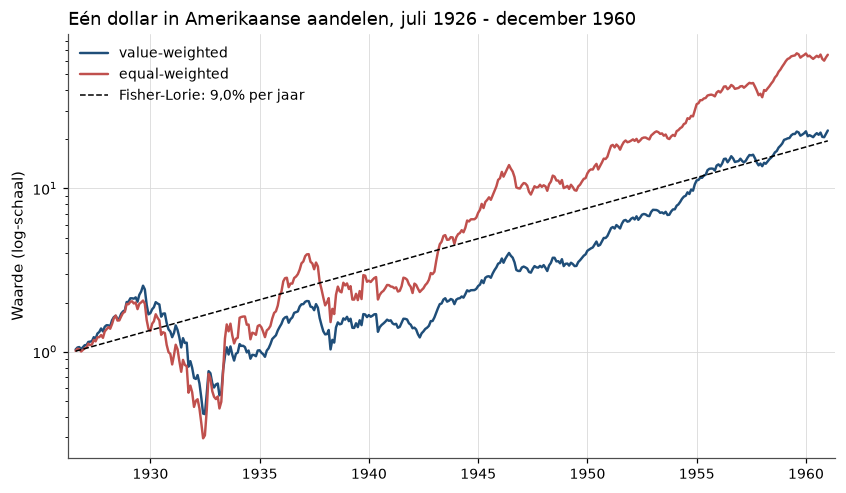

In [10]:
cumulative = pd.DataFrame(
    {"value-weighted": (1 + value_weighted).cumprod(),
     "equal-weighted": (1 + equal_weighted).cumprod()}
)
years_elapsed = np.arange(1, len(cumulative) + 1) / 12
path_9pct = 1.09 ** years_elapsed

fig, ax = plt.subplots()
for column, color in zip(cumulative.columns, hap.plotting.COLORS):
    ax.plot(cumulative.index, cumulative[column], label=column, color=color)
ax.plot(cumulative.index, path_9pct, color="black", ls="--", lw=1.0,
        label="Fisher-Lorie: 9,0% per jaar")
ax.set_yscale("log")
ax.set_title("Eén dollar in Amerikaanse aandelen, juli 1926 - december 1960")
ax.set_xlabel("Jaar")
ax.set_ylabel("Waarde (log-schaal)")
ax.legend()
hap.plotting.timeline_axis(ax)
plt.show()

:::{figure} #cel-rendementen-fisherlorie
:label: fig-rendementen-fisherlorie
:width: 90%

De periode die Fisher en Lorie bekeken. De stippellijn groeit met hun 9,0% per
jaar. De value-weighted reeks eindigt er vlak boven, de equal-weighted reeks ver
erboven. De crash van 1929–1932, een terugval van meer dan 80%, zit er volledig
in. Daarom vonden tijdgenoten het resultaat opzienbarend: zelfs met de Grote
Depressie erbij was het langetermijnrendement ruim positief.
:::

### Dezelfde eeuw, maand- en dagdata

Deze subsectie en de volgende zijn geen replicatie maar illustraties van
[](#thm-rendementen-merton) op echte data. De verwachting: dagdata verbeteren de
standaardfout van het gemiddelde nauwelijks, en de schatting van volatiliteit en
staarten sterk. We nemen de hele French-reeks van juli 1926 tot
juli 2026, op maand- en op dagbasis. Tot 1952 werd ook op zaterdag gehandeld.
Daarom annualiseren we de dagreeks met het werkelijke aantal handelsdagen per
jaar, niet met 252.

In [11]:
market_monthly = hap_data.market_monthly()["Mkt"].dropna()
market_daily = hap_data.market_daily()["Mkt"].dropna()
calendar_years = len(market_monthly) / 12
days_per_year = len(market_daily) / calendar_years

def describe_frequency(returns: pd.Series, per_year: float) -> dict[str, float]:
    '''Annual summary plus log volatility, signal-to-noise ratios and log excess kurtosis.'''
    summary = annual_summary(returns, per_year)
    summary["volatiliteit logrendement"] = np.log1p(returns).std(ddof=1) * np.sqrt(per_year)
    summary["signaal/ruis per waarneming"] = returns.mean() / returns.std(ddof=1)
    summary["signaal/ruis per jaar"] = summary["rekenkundig"] / summary["volatiliteit"]
    summary["excess kurtosis (log)"] = np.log1p(returns).kurtosis()
    return summary


comparison = pd.DataFrame(
    {
        "maandelijks": describe_frequency(market_monthly, 12),
        "dagelijks": describe_frequency(market_daily, days_per_year),
    }
)
comparison.round(4)

,maandelijks,dagelijks
waarnemingen,1201.0000,26296.0000
meetkundig,0.1035,0.1026
rekenkundig,0.1157,0.1130
volatiliteit,0.1834,0.1746
SE van het gemiddelde,0.0183,0.0175
volatiliteit logrendement,0.1832,0.1749
signaal/ruis per waarneming,0.1822,0.0399
signaal/ruis per jaar,0.6310,0.6471
excess kurtosis (log),6.4977,16.9899


De tabel laat zien wat de stelling van Merton voorspelt. De dagreeks heeft 22
keer zoveel waarnemingen, maar de standaardfout van het gemiddelde daalt alleen
van 1,83 naar 1,75 procentpunt. Ook die kleine daling komt van een lagere
volatiliteit, niet van meer waarnemingen. De 1,83 is de gemeten tegenhanger van
de standaardfout van 2%, met een gemeten volatiliteit onder de ronde 20%.

Dat de volatiliteit op dagbasis lager uitvalt, volgt uit [](#eq-rendementen-vr)
met dagen binnen een maand. Dagrendementen zijn licht positief gecorreleerd (zie
de tabel hierna), zodat een maand meer schommelt dan de dagen apart doen
vermoeden. De excess kurtosis springt omhoog: de dagreeks vertelt veel meer over
de staarten en niets meer over het midden.

### Wat wél in de data zit: clustering van volatiliteit

Het rendement zelf heeft nauwelijks geheugen, de volatiliteit wel. De tabel toont
de autocorrelatie van het logrendement en van het absolute logrendement, een maat
voor de volatiliteit van die dag.

In [12]:
log_daily = np.log1p(market_daily)
log_monthly = np.log1p(market_monthly)

diagnostics = pd.DataFrame(
    {
        "autocorr. rendement (dag)": [log_daily.autocorr(k) for k in range(1, 7)],
        "autocorr. |rendement| (dag)": [log_daily.abs().autocorr(k) for k in range(1, 7)],
        "autocorr. rendement (maand)": [log_monthly.autocorr(k) for k in range(1, 7)],
    },
    index=pd.Index(range(1, 7), name="lag"),
)
diagnostics.round(3)

,autocorr. rendement (dag),autocorr. |rendement| (dag),autocorr. rendement (maand)
lag,,,
1,0.047,0.299,0.085
2,-0.024,0.332,-0.022
3,0.001,0.316,-0.074
4,0.016,0.306,0.021
5,0.009,0.311,0.069
6,-0.025,0.304,-0.025


De autocorrelatie van het rendement is bij elke lag kleiner dan 0,09 en bij de
meeste kleiner dan 0,03. Die van het absolute rendement is ongeveer 0,30, bij lag
1 en nog bij lag 6: volatiliteit klontert. Zo staat de asymmetrie nog één keer
in de data. De grootheid die we goed kunnen meten, is ook voorspelbaar. De
grootheid die we slecht kunnen meten, vertoont nauwelijks een patroon.

## Wat er brak, en wat daarna kwam

**Wat de meetlat oplevert.** Met [](#eq-rendementen-additief),
[](#eq-rendementen-wortelt) en [](#eq-rendementen-se) wordt elke bewering over
een gemiddeld rendement een uitspraak met een standaardfout erbij. Die vertaling
vraagt geen model, geen aanname over voorkeuren en geen theorie. Van elke
schatter is de precisie bekend, en dat kunnen weinig vakgebieden van hun meetlat
zeggen.

**Waar het breekt.** Het instrument is scherp genoeg om zijn eigen grenzen te
tonen. Het rekenkundig gemiddelde marktrendement was 11,7% over 1926–1960, met
een standaardfout van 3,9 procentpunt, en 11,6% over de hele eeuw, met 1,8. Geen
frequentie of methode verbetert dat, want volgens [](#thm-rendementen-merton)
zit de informatie over de drift alleen in de kalenderlengte. Het verwachte
rendement in elke waarderingsvergelijking is dus niet nauwkeuriger bekend dan op
een paar procentpunt.

**Risico of vergissing?** Stel dat de markt in 1932 goedkoop was. Volgens de
Chicago-lezing (Fama: prijzen kloppen) eisten beleggers voor het risico van dat
moment een hogere vergoeding. Volgens de Yale-lezing (Shiller: prijzen kunnen
ernaast zitten) stond de prijs door paniek te laag. Beide voorspellen hoge
rendementen na 1932. Ze verschillen in welk deel daarvan vergoeding voor risico
was: het verwachte rendement volgens een risicomodel, tegen het rendement dat
volgde. Is dat verschil twee procentpunt per jaar, dan kost het volgens
[](#eq-rendementen-jaren) vierhonderd jaar data om het te zien, en een crisis
levert er hooguit een paar. De data zijn te dun om te kiezen.

**Wat er daarna kwam.** De wortel-$t$-regel [](#eq-rendementen-wortelt) komt niet
uit een statistiekboek maar van een handelsvloer. In 1863 schreef Jules Regnault,
beambte aan de Parijse beurs, dat de koersuitslag met de wortel van de tijd
groeit: 37 jaar vóór Bachelier. Daarover gaat [](#01-02-bachelier): de regel als
empirisch feit, de Brownse beweging als model erachter, en de eerste toetsen of
koersen geheugenloos zijn.

## Oefeningen

:::{exercise}
:label: ex-rendementen-instap

**Instap: het toy-voorbeeld gevarieerd.**

1. Zet de drie rendementen in omgekeerde volgorde: $+10\%$, $-20\%$, $+25\%$.
   Welke getallen uit het toy-voorbeeld veranderen?
2. Vervang $-20\%$ door $-30\%$. Bereken het rekenkundig en het meetkundig
   gemiddelde en de halve variantie. Wordt het verschil tussen de twee
   gemiddelden groter of kleiner, en waarom?
:::

:::{solution} ex-rendementen-instap
:class: dropdown

**(1)** Geen enkel getal. De som, het product en de variantie hangen niet af van
de volgorde.

**(2)** Het rekenkundig gemiddelde is $(0{,}25 - 0{,}30 + 0{,}10)/3 = 0{,}016667$.
Het product van de bruto rendementen is $1{,}25 \times 0{,}70 \times 1{,}10 =
0{,}9625$, dus het meetkundig gemiddelde is $0{,}9625^{1/3} - 1 = -0{,}012660$.
De afwijkingen van het gemiddelde zijn $0{,}233333$, $-0{,}316667$ en
$0{,}083333$, met een kwadratensom van $0{,}161667$. Gedeeld door drie is dat
$0{,}053889$, en de halve variantie is $0{,}026944$. De cel rekent het na.

In [13]:
r_alt = np.array([0.25, -0.30, 0.10])
arith_alt = r_alt.mean()
geom_alt = (1 + r_alt).prod() ** (1 / len(r_alt)) - 1
half_var_alt = r_alt.var(ddof=0) / 2

pd.Series({
    "rekenkundig gemiddelde": arith_alt,
    "meetkundig gemiddelde": geom_alt,
    "halve variantie": half_var_alt,
    "verschil rekenkundig - meetkundig": arith_alt - geom_alt,
}).round(6)

rekenkundig gemiddelde               0.016667
meetkundig gemiddelde               -0.012660
halve variantie                      0.026944
verschil rekenkundig - meetkundig    0.029326
dtype: float64

Het verschil groeit van 1,77 naar 2,93 procentpunt, omdat het grotere verlies de
variantie vergroot. Het rekenkundig gemiddelde is nog positief, maar de belegger
heeft geld verloren. Wat dit leert: een positief gemiddeld rendement zegt nog
niets over het vermogen aan het eind.
:::

:::{exercise}
:label: ex-rendementen-1

**De twee standaardfouten, afgeleid en gesimuleerd.**

1. Leid [](#eq-rendementen-merton) af zonder continue tijd. Neem $N = nT$
   onafhankelijke stappen $\ell_i \sim N(\nu/n, \sigma^2/n)$ en toon aan dat de
   geannualiseerde schatter $\hat\nu = (n/N)\sum_i \ell_i$ variantie $\sigma^2/T$
   heeft, ongeacht $n$.
2. Een onderzoeker beweert dat de premie 6% is, een ander 4%. Hoeveel jaar data
   is nodig om die twee met $t = 2$ te scheiden, bij $\sigma = 20\%$? En bij
   $\sigma = 15\%$?
3. Simuleer 20 000 steekproeven van 100 jaarlijkse rendementen met
   $\mu = 6\%$ en $\sigma = 20\%$. In welke fractie is de geschatte premie
   negatief? In welke fractie haalt hij $t > 2$?
:::

:::{solution} ex-rendementen-1
:class: dropdown

**(1)** De som $\sum_{i=1}^{N}\ell_i$ heeft gemiddelde $N\nu/n = T\nu$ en
variantie $N\sigma^2/n = T\sigma^2$. Dus $\hat\nu = (1/T)\sum_i \ell_i$ heeft
$\E[\hat\nu] = \nu$ en $\Var(\hat\nu) = T\sigma^2/T^2 = \sigma^2/T$, zonder $n$.
Elke stap is $n$ keer kleiner en $n$ keer minder variabel, maar er zijn er $n$
keer zoveel.

**(2)** Met [](#eq-rendementen-jaren), $\tau = 2$ en $\mu_1 - \mu_0 = 0{,}02$:
$(2 \times 0{,}20/0{,}02)^2 = 400$ jaar bij $\sigma = 20\%$ en
$(2 \times 0{,}15/0{,}02)^2 = 225$ jaar bij $\sigma = 15\%$.

**(3)** Analytisch is de standaardfout $20/\sqrt{100} = 2$ procentpunt. Een
negatieve schatting vraagt dan een afwijking van drie standaardfouten, met kans
$\Phi(-3) \approx 0{,}13\%$. De cel rekent (2) na en simuleert (3).

In [14]:
n_sim, n_obs, mu_ex, sigma_ex = 20_000, 100, 0.06, 0.20
draws = rng.normal(mu_ex, sigma_ex, size=(n_sim, n_obs))
sample_mean = draws.mean(axis=1)
sample_t = sample_mean / (draws.std(axis=1, ddof=1) / np.sqrt(n_obs))

pd.DataFrame(
    {
        "waarde": [
            (2 * 0.20 / 0.02) ** 2,
            (2 * 0.15 / 0.02) ** 2,
            float(np.mean(sample_mean < 0)),
            float(np.mean(sample_t > 2)),
        ]
    },
    index=["jaren nodig bij sigma=20%", "jaren nodig bij sigma=15%",
           "fractie met negatieve geschatte premie", "fractie met t > 2"],
).round(4)

,waarde
jaren nodig bij sigma=20%,400.0000
jaren nodig bij sigma=15%,225.0000
fractie met negatieve geschatte premie,0.0016
fractie met t > 2,0.8442


In 0,16% van de gesimuleerde eeuwen concludeert een onderzoeker met een perfect
gespecificeerd model dat aandelen minder opbrengen dan niets, dicht bij de
analytische 0,13%. In ongeveer 84% haalt hij $t > 2$: de toets of de premie nul
is, werkt behoorlijk. Wat dit leert: óf er een premie is, is met een eeuw data
te beantwoorden, hoe groot hij is niet.
:::

:::{exercise}
:label: ex-rendementen-2

**Fisher-Lorie op andere steekproeven.** Herhaal de replicatie voor 1926-07 t/m
1960-12, 1961-01 t/m 1993-12 en 1994-01 t/m 2026-07.

1. Rapporteer per periode het meetkundig en het rekenkundig gemiddelde per jaar
   van het totaalrendement van de value-weighted markt, de volatiliteit en de
   standaardfout van het gemiddelde.
2. Toets of het rekenkundig gemiddelde van de eerste periode verschilt van dat
   van de derde. Neem aan dat de perioden onafhankelijk zijn.
3. Hoe lang zou elke periode moeten duren om een verschil van twee procentpunt
   met $t = 2$ te zien?
:::

:::{solution} ex-rendementen-2
:class: dropdown

Eerst de samenvatting per periode.

In [15]:
periods = {
    "1926-07 / 1960-12": slice("1926-07", "1960-12"),
    "1961-01 / 1993-12": slice("1961-01", "1993-12"),
    "1994-01 / 2026-07": slice("1994-01", "2026-07"),
}
market = hap_data.market_monthly()["Mkt"]

by_period = pd.DataFrame(
    {name: annual_summary(market.loc[window]) for name, window in periods.items()}
).T
by_period.round(4)

,waarnemingen,meetkundig,rekenkundig,volatiliteit,SE van het gemiddelde
1926-07 / 1960-12,414.0,0.0946,0.1167,0.2293,0.0390
1961-01 / 1993-12,396.0,0.1073,0.1143,0.1538,0.0268
1994-01 / 2026-07,391.0,0.1092,0.1161,0.1543,0.0270


De rekenkundige gemiddelden liggen dicht bij elkaar, de meetkundige lopen
uiteen. Dan het verschil tussen de eerste en de laatste periode. Voor twee
onafhankelijke gemiddelden over elk $T$ jaar is de standaardfout van het verschil
$\sqrt{(\sigma_1^2 + \sigma_3^2)/T}$; $t = 2$ bij een verschil $\Delta$ vraagt
dus $T = 4(\sigma_1^2 + \sigma_3^2)/\Delta^2$.

In [16]:
first, last = by_period.index[0], by_period.index[-1]
difference = by_period.loc[first, "rekenkundig"] - by_period.loc[last, "rekenkundig"]
se_difference = np.sqrt(
    by_period.loc[first, "SE van het gemiddelde"] ** 2
    + by_period.loc[last, "SE van het gemiddelde"] ** 2
)
vol_first = by_period.loc[first, "volatiliteit"]
vol_last = by_period.loc[last, "volatiliteit"]
years_for_2pp = 4 * (vol_first**2 + vol_last**2) / 0.02**2

pd.DataFrame(
    {"waarde": [difference, se_difference, difference / se_difference, years_for_2pp]},
    index=["verschil in rekenkundig gemiddelde", "standaardfout van het verschil",
           "t-waarde", "jaren per periode voor t=2 bij 2 pp verschil"],
).round(4)

,waarde
verschil in rekenkundig gemiddelde,0.0007
standaardfout van het verschil,0.0475
t-waarde,0.0137
jaren per periode voor t=2 bij 2 pp verschil,763.8969


De rekenkundige gemiddelden van de drie perioden liggen binnen een kwart
procentpunt van elkaar, met een $t$-waarde van 0,01 tussen de eerste en de
laatste. Het meetkundig gemiddelde stijgt wel, van 9,46% naar 10,92%. Dat komt
uit [](#thm-rendementen-drag): de volatiliteit daalde van 22,9% naar ruim 15%,
en een kleinere halve variantie geeft meer groei bij hetzelfde verwachte
rendement. Wie de twee gemiddelden door elkaar haalt, ziet een stijging die er
niet is. Let wel: dit is het totaalrendement, niet de premie, want de risicovrije
rente verschilde sterk per periode.

Om een verschil van twee procentpunt te zien, zou elke periode ruim
zevenhonderd jaar moeten duren. Wat dit leert: een veranderd meetkundig
gemiddelde is nog geen veranderd verwacht rendement, en een echt veranderd
verwacht rendement is met rendementsdata alleen niet te zien.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->